In [1]:
from vmc_ising import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
    reconstruct_signs,
    find_sign_overlap,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd

Running dilated_nns_xors.py


In [2]:
def get_energy(signs, system, log_prob_fn):
    probs = safe_exp(
        (log_prob_fn(torch.from_numpy(system.basis.states.astype(np.int64))) / 2),
        normalise=True,
    ).view(-1).detach().numpy()
    
    amplitudes = np.sqrt(probs)
    wavefunction = signs * amplitudes
    return (system.hamiltonian @ wavefunction) @ wavefunction


In [3]:
df = read_jsonl_to_df(output_dir.glob("*/results.jsonl")).fillna(
    keep_serializable(default_config)
)

/gpfs/home1/ishchurov/frustrations-eda/misc_utils.py:206: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dataframes).reset_index(drop=True)


In [4]:
task_id = 51
config = get_config(task_id)
system = get_system(config)
system.get_eigenstates(1)
log_prob_fn = get_network(config, get_system(config))

2024-03-12 21:17:00.620 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-03-12 21:17:00.620 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-03-12 21:17:00.621 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-03-12 21:17:00.621 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-03-12 21:17:00.703 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-03-12 21:17:00.711 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-False-None-10.pickle
2024-03-12 21:17:00.786 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923
2024-03-12 21:17:00.793 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-03-12 21:17:00.794 | DEBUG    | heisenberg_hami

In [5]:
step = 80
true_signs = np.sign(system.get_ground_state())
log_prob_fn.load_state_dict(
    torch.load(
        output_dir / f"{task_id}/log_prob_fn_{step}.pt",
        map_location=torch.device("cpu"),
    )
)

<All keys matched successfully>

In [10]:
signs_greedy = torch.load(output_dir / f"{task_id}/reconstructed_signs_{step}.pt")

In [11]:
signs_greedy

array([ 1., -1.,  1., ...,  1.,  1., -1.])

In [ ]:
get_energy()

In [50]:
reconstructed_signs_list = []
for step in range(0, 15000, 100):
    log_prob_fn.load_state_dict(
        torch.load(
            output_dir / f"{task_id}/log_prob_fn_{step}.pt",
            map_location=torch.device("cpu"),
        )
    )
    reconstructed_signs_list.append(
        reconstruct_signs(
            system,
            log_prob_fn,
            number_sweeps=config["sign_reconstruction.number_sweeps"],
            how=config["sign_reconstruction.method"],
            repetitions=config["sign_reconstruction.repetitions"],
        )
    )

In [51]:
reconstructed_signs_list = reconstructed_signs

In [52]:
ising_energy = []
previous_reconstructed_signs = None
for step, reconstructed_signs in zip(range(0, 15000, 100), reconstructed_signs_list):
    log_prob_fn.load_state_dict(
        torch.load(
            output_dir / f"{task_id}/log_prob_fn_{step}.pt",
            map_location=torch.device("cpu"),
        )
    )
    if previous_reconstructed_signs is not None:
        sign_overlap_incremental = (
            reconstructed_signs
            * previous_reconstructed_signs
            * system.get_ground_state() ** 2
        ).sum()
    else:
        sign_overlap_incremental = None
    sign_overlap_with_true = find_sign_overlap(system, reconstructed_signs)

    previous_reconstructed_signs = reconstructed_signs
    ising_energy.append(
        dict(
            ising_energy_reconstructed_signs=get_energy(
                reconstructed_signs, system, log_prob_fn
            ),
            ising_energy_true_signs=get_energy(true_signs, system, log_prob_fn),
            step=step,
            sign_overlap_incremental=sign_overlap_incremental,
            sign_overlap_with_true=sign_overlap_with_true,
        )
    )
    # system.hamiltonian @ wavefunction

<Axes: xlabel='step'>

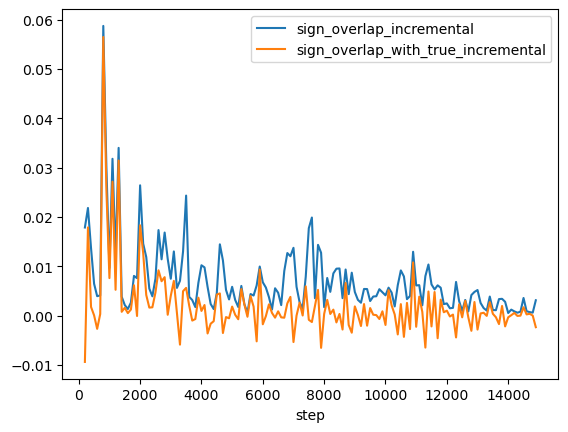

In [58]:
pd.DataFrame(ising_energy).assign(
    delta=lambda df: df["ising_energy_reconstructed_signs"]
    - df["ising_energy_true_signs"],
    sign_overlap_incremental=lambda df: 1 - df["sign_overlap_incremental"].abs(),
    sign_overlap_with_true_incremental=lambda df: df["sign_overlap_with_true"].diff()
).set_index("step").iloc[2:][["sign_overlap_incremental", "sign_overlap_with_true_incremental"]].plot()

In [63]:
pd.DataFrame(ising_energy).assign(
    delta=lambda df: df["ising_energy_reconstructed_signs"]
    - df["ising_energy_true_signs"],
    sign_overlap_incremental=lambda df: 1 - df["sign_overlap_incremental"].abs(),
    sign_overlap_with_true_incremental=lambda df: df["sign_overlap_with_true"].diff()
).query("step > 10000")['sign_overlap_incremental'].mean()

0.0036988500363071314

In [60]:
pd.DataFrame(ising_energy).assign(
    delta=lambda df: df["ising_energy_reconstructed_signs"]
    - df["ising_energy_true_signs"],
    sign_overlap_incremental=lambda df: 1 - df["sign_overlap_incremental"].abs(),
    sign_overlap_with_true_incremental=lambda df: df["sign_overlap_with_true"].diff()
)['sign_overlap_with_true']

0      0.017012
1      0.646373
2      0.636964
3      0.654824
4      0.656566
         ...   
145    0.950284
146    0.950510
147    0.950858
148    0.950843
149    0.948475
Name: sign_overlap_with_true, Length: 150, dtype: float64